In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    BertTokenizer, BertForSequenceClassification
)
from peft import PeftModel
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
import time

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Use: {device}")

Use: mps


In [38]:
def load_local_financial_phrasebank(filepath):
    sentences, labels = [], []
    with open(filepath, encoding="iso-8859-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            sentence, label = line.rsplit("@", 1)
            sentences.append(sentence)
            labels.append(label.strip())
    
    label_mapping = {"negative": 0, "neutral": 1, "positive": 2}
    labels = [label_mapping[l] for l in labels]
    
    # 10% test set
    np.random.seed(42)
    indices = np.random.permutation(len(sentences))
    test_size = int(len(sentences) * 0.1)
    test_indices = indices[:test_size]
    
    test_sentences = [sentences[i] for i in test_indices]
    test_labels = [labels[i] for i in test_indices]
    
    return test_sentences, test_labels

In [39]:
# evaluation func
def evaluate_model(model, tokenizer, sentences, labels, model_name="Model", batch_size=16):
    model = model.to(device)
    model.eval()
    
    all_preds = []
    inference_times = []
    
    for i in tqdm(range(0, len(sentences), batch_size), desc=f"Evaluating {model_name}"):
        batch_sentences = sentences[i:i+batch_size]
        batch_labels = labels[i:i+batch_size]
        
        # Tokenize
        inputs = tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)
        
        start_time = time.time()
        with torch.no_grad():
            outputs = model(**inputs)
        inference_times.append(time.time() - start_time)
        
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
    
    # calc indices
    accuracy = accuracy_score(labels, all_preds)
    f1 = f1_score(labels, all_preds, average='weighted')
    precision, recall, _, _ = precision_recall_fscore_support(labels, all_preds, average='weighted')
    
    per_class = precision_recall_fscore_support(labels, all_preds, average=None, labels=[0,1,2])
    
    results = {
        "model_name": model_name,
        "accuracy": accuracy,
        "weighted_f1": f1,
        "precision": precision,
        "recall": recall,
        "confusion_matrix": confusion_matrix(labels, all_preds),
        "predictions": all_preds,
        "true_labels": labels,
        "per_class_precision": per_class[0],
        "per_class_recall": per_class[1],
        "per_class_f1": per_class[2],
        "avg_inference_time_per_batch": np.mean(inference_times),
    }
    
    return results

In [40]:
def evaluate_finbert(model, tokenizer, sentences, labels, model_name="FinBERT", batch_size=16):
    """
    FinBERT mapping:
        - input: 0=positive, 1=negative, 2=neutral
        - target: 0=negative, 1=neutral, 2=positive
    
    Args:
        labels:  (0=negative, 1=neutral, 2=positive)
    
    Returns:
        results: dict
    """
    model = model.to(device)
    model.eval()
    
    all_preds_raw = []  # FinBERT raw predictions
    inference_times = []
    
    for i in tqdm(range(0, len(sentences), batch_size), desc=f"Evaluating {model_name}"):
        batch_sentences = sentences[i:i+batch_size]
        
        # Tokenize
        inputs = tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)
        
        start_time = time.time()
        with torch.no_grad():
            outputs = model(**inputs)
        inference_times.append(time.time() - start_time)
        
        # FinBERT raw pred: 0=positive, 1=negative, 2=neutral
        preds_raw = torch.argmax(outputs.logits, dim=-1)
        all_preds_raw.extend(preds_raw.cpu().numpy())
    
    # remapping
    # 0 (positive) -> 2 (positive in target)
    # 1 (negative) -> 0 (negative in target)
    # 2 (neutral)  -> 1 (neutral in target)
    remap = {0: 2, 1: 0, 2: 1}
    all_preds_mapped = [remap[p] for p in all_preds_raw]

    # calc indices
    accuracy = accuracy_score(labels, all_preds_mapped)
    f1 = f1_score(labels, all_preds_mapped, average='weighted')
    precision, recall, _, _ = precision_recall_fscore_support(labels, all_preds_mapped, average='weighted')
    
    per_class = precision_recall_fscore_support(labels, all_preds_mapped, average=None, labels=[0, 1, 2])
    
    results = {
        "model_name": model_name,
        "accuracy": accuracy,
        "weighted_f1": f1,
        "precision": precision,
        "recall": recall,
        "confusion_matrix": confusion_matrix(labels, all_preds_mapped),
        "predictions": all_preds_mapped,      
        "predictions_raw": all_preds_raw,     
        "true_labels": labels,
        "per_class_precision": per_class[0],
        "per_class_recall": per_class[1],
        "per_class_f1": per_class[2],
        "avg_inference_time_per_batch": np.mean(inference_times),
    }
    
    return results

In [41]:
# load finetuned model
base_model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
adapter_path = "./fin_deepseek_lora_mac/final"  

# load base model
base_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=3,
    id2label={0: "negative", 1: "neutral", 2: "positive"},
    label2id={"negative": 0, "neutral": 1, "positive": 2}
)

# LoRA adapter
my_model = PeftModel.from_pretrained(base_model, adapter_path)
my_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
if my_tokenizer.pad_token is None:
    my_tokenizer.pad_token = my_tokenizer.eos_token
if my_model.config.pad_token_id is None:
    my_model.config.pad_token_id = my_tokenizer.eos_token_id
print("model loaded")

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 7501.28it/s]
Qwen2ForSequenceClassification LOAD REPORT from: deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model loaded


In [42]:
# load FinBERT
finbert_model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert", num_labels=3, use_safetensors=True)
finbert_tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")

# adjust labels
finbert_model.config.id2label = {0: "negative", 1: "neutral", 2: "positive"}
finbert_model.config.label2id = {"negative": 0, "neutral": 1, "positive": 2}

print("FinBERT loaded")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8934.55it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded


In [43]:
data_path = "FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"
test_sentences, test_labels = load_local_financial_phrasebank(data_path)

In [44]:
# evaluation
all_results = {}

print("\n>>> evaluate my model")
my_results = evaluate_model(my_model, my_tokenizer, test_sentences, test_labels, "MyModel")
all_results["MyModel"] = my_results

print("\n>>> evaluate FinBERT")
finbert_results = evaluate_finbert(finbert_model, finbert_tokenizer, test_sentences, test_labels, "FinBERT")
all_results["FinBERT"] = finbert_results

print("\n" + "="*70)
print("model performance")
print("="*70)
print(f"{'Model':<30} {'Accuracy':<12} {'Weighted F1':<12} {'Precision':<12}")
print("-"*70)

for name, res in all_results.items():
    print(f"{name:<30} {res['accuracy']:.4f}       {res['weighted_f1']:.4f}       {res['precision']:.4f}")
print("="*70)


>>> evaluate my model


Evaluating MyModel: 100%|██████████| 15/15 [00:16<00:00,  1.13s/it]



>>> evaluate FinBERT


Evaluating FinBERT: 100%|██████████| 15/15 [00:01<00:00,  8.89it/s]


model performance
Model                          Accuracy     Weighted F1  Precision   
----------------------------------------------------------------------
MyModel                        0.9956       0.9956       0.9957
FinBERT                        0.9735       0.9737       0.9750


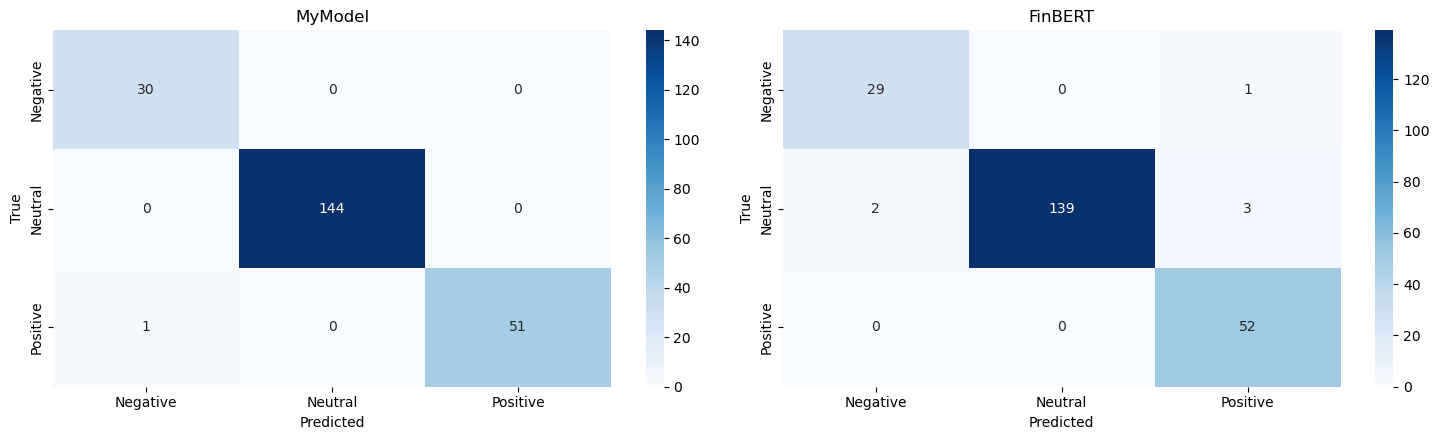

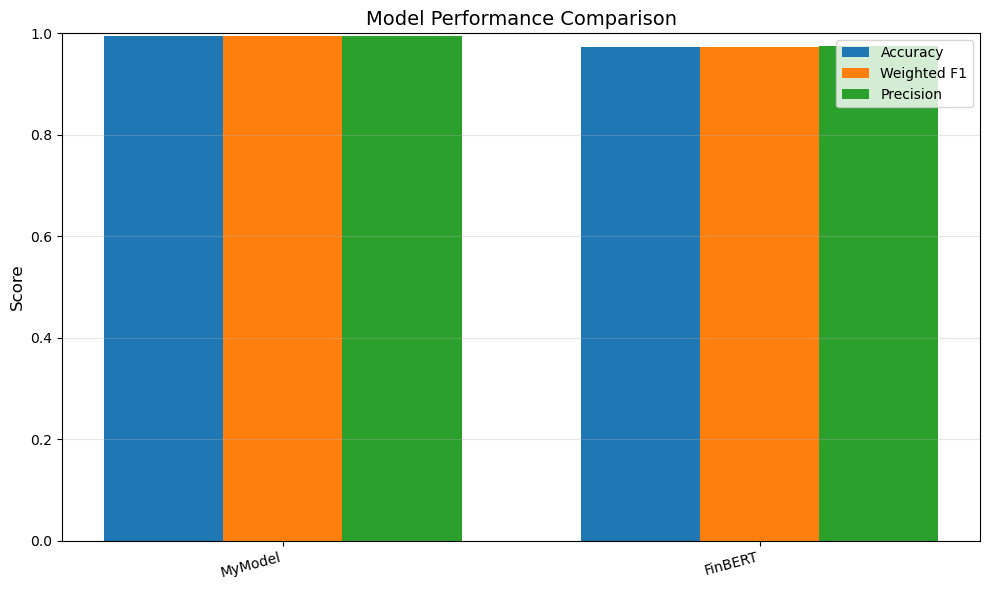

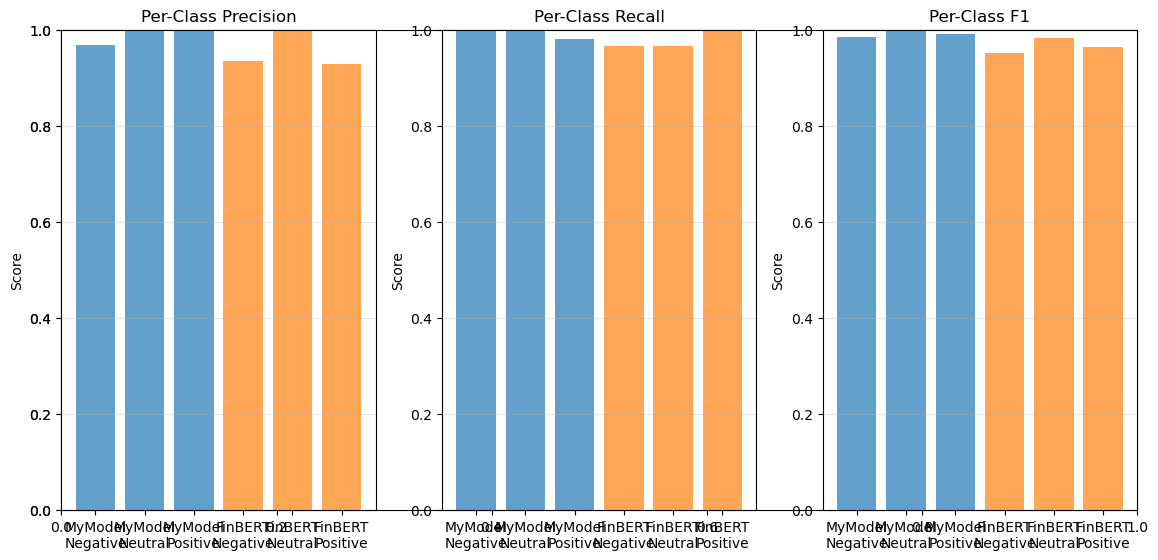

In [45]:
# visualization
# confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
label_names = ['Negative', 'Neutral', 'Positive']

for idx, (name, res) in enumerate(all_results.items()):
    sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[idx])
    axes[idx].set_title(f'{name}', fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# performance bar plot
fig, ax = plt.subplots(figsize=(10, 6))

models = list(all_results.keys())
metrics = ['accuracy', 'weighted_f1', 'precision']
x = np.arange(len(models))
width = 0.25

for i, metric in enumerate(metrics):
    scores = [all_results[m][metric] for m in models]
    bars = ax.bar(x + i*width, scores, width, label=metric.replace('_', ' ').title())

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# classes performance
fig, ax = plt.subplots(figsize=(12, 6))

classes = ['Negative', 'Neutral', 'Positive']
metrics = ['precision', 'recall', 'f1']

for i, metric in enumerate(metrics):
    ax = plt.subplot(1, 3, i+1)
    for name, res in all_results.items():
        scores = res[f'per_class_{metric}']
        ax.bar([f"{name}\n{c}" for c in classes], scores, alpha=0.7)
    ax.set_ylim(0, 1)
    ax.set_title(f'Per-Class {metric.title()}')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# save result
# to CSV
results_df = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": res['accuracy'],
        "Weighted F1": res['weighted_f1'],
        "Precision": res['precision'],
        "Recall": res['recall']
    }
    for name, res in all_results.items()
])
results_df.to_csv("evaluation_results.csv", index=False)

In [47]:
# LaTeX 
latex_table = """
\\begin{table}[h]
\\centering
\\caption{Model Performance Comparison on Financial PhraseBank}
\\label{tab:results}
\\begin{tabular}{lcccc}
\\hline
\\textbf{Model} & \\textbf{Accuracy} & \\textbf{Weighted F1} & \\textbf{Precision} & \\textbf{Recall} \\\\
\\hline
"""
for _, row in results_df.iterrows():
    latex_table += f"{row['Model']} & {row['Accuracy']:.3f} & {row['Weighted F1']:.3f} & {row['Precision']:.3f} & {row['Recall']:.3f} \\\\\n"
latex_table += """\\hline
\\end{tabular}
\\end{table}
"""

with open("results_table.tex", "w") as f:
    f.write(latex_table)

print("\n" + latex_table)



\begin{table}[h]
\centering
\caption{Model Performance Comparison on Financial PhraseBank}
\label{tab:results}
\begin{tabular}{lcccc}
\hline
\textbf{Model} & \textbf{Accuracy} & \textbf{Weighted F1} & \textbf{Precision} & \textbf{Recall} \\
\hline
MyModel & 0.996 & 0.996 & 0.996 & 0.996 \\
FinBERT & 0.973 & 0.974 & 0.975 & 0.973 \\
\hline
\end{tabular}
\end{table}



In [48]:
# error sample analysis
print("\n" + "="*70)
print("error sample analysis")
print("="*70)

preds = my_results['predictions']
trues = my_results['true_labels']
errors = [(test_sentences[i], trues[i], preds[i]) for i in range(len(test_sentences)) if trues[i] != preds[i]]

label_names_rev = {0: "negative", 1: "neutral", 2: "positive"}
print(f"total errors: {len(errors)}/{len(test_sentences)} ({len(errors)/len(test_sentences)*100:.1f}%)")
print("\nfirst 10 error samples:")
for i, (text, true, pred) in enumerate(errors[:10]):
    print(f"{i+1}. True: {label_names_rev[true]} -> Pred: {label_names_rev[pred]}")
    print(f"   Text: {text[:80]}...")
    print()

print("\nevaluation done. files to be checked:")
print("   - confusion_matrices.png")
print("   - performance_comparison.png")
print("   - per_class_performance.png")
print("   - evaluation_results.csv")
print("   - results_table.tex")


error sample analysis
total errors: 1/226 (0.4%)

first 10 error samples:
1. True: positive -> Pred: negative
   Text: Metsaliitto , however , narrowed its net loss for the second quarter of 2007 to ...


evaluation done. files to be checked:
   - confusion_matrices.png
   - performance_comparison.png
   - per_class_performance.png
   - evaluation_results.csv
   - results_table.tex
